# Analysis of the Australian Frogs dataset

Group: A Leap of Faith

Members: Shreya Sriram(A0327236E), Aparna Krishna(A0326884N), Apurwa Kumari (A0333260R), Aditya Vijindra Pandhari (A0328873R), Vanshika Dhamija (A0333989H)

**Table of Contents**<a id='toc0_'></a>

- [1. Introduction](#toc1_)
  - [1.1. Dataset](#toc1_1)
  - [1.2. Research Question](#toc1_2)
- [2. Data Cleaning and Preprocessing](#toc2_)
  - [2.1. Checking scientific name overlap between datasets](#toc2_1_)
  - [2.2. Resolving unmatched scientific names](#toc2_2_)
  - [2.3. Validating occurrence ID uniqueness](#toc2_3_)
  - [2.4. Checking coordinate validity](#toc2_4_)
  - [2.5. Checking state and province values](#toc2_5_)
  - [2.6. Parsing event dates for seasonal analysis](#toc2_6_)
  - [2.7. Checking coordinate uncertainty](#toc2_7_)
  - [2.8. Merging the cleaned datasets](#toc2_8_)
  - [2.9. Deriving a region attribute](#toc2_9_)
  - [2.10. Writing the cleaned dataset](#toc2_10_)
- [3. Visualisation](#toc3_)
  - [3.1. Top 10 most observed frog species](#toc3_1_)
  - [3.2. Monthly observations by region](#toc3_2_)
  - [3.3. Seasonal observation density map](#toc3_3_)
- [4. Discussion](#toc4_)
- [5. Teamwork](#toc5_)
- [6. References](#toc6_)

## 1. Introduction<a id='toc1_'></a>

Australia is home to over 250 known frog species, many of which are found nowhere else on Earth. Despite their ecological importance, roughly one in five Australian frog species is currently threatened with extinction, driven by factors including climate change, urbanisation, disease, and invasive species.

This analysis draws on 2023 data from the FrogID project, a citizen science initiative run by the Australian Museum. Volunteers across the country use a smartphone app to record frog calls, which are then verified by expert researchers. The dataset used here - FrogID 6.0 - contains 136,621 verified observations spanning January to November 2023. Each observation includes the species name, GPS coordinates, date and time of recording, and the state or territory in which it was made. A companion reference table provides common names and taxonomic classifications for each species.

### 1.1. Dataset<a id='toc1_1'></a>



Two datasets are used in this analysis, both sourced from the TidyTuesday repository (Week 35, 2025):

- **`frogID_data`** — 136,621 observation records with fields including `scientificName`, `decimalLatitude`, `decimalLongitude`, `eventDate`, `eventTime`, `stateProvince`, and `coordinateUncertaintyInMeters`.
- **`frog_names`** — A reference table of 294 entries mapping `scientificName` to `commonName`, `subfamily`, `tribe`, and `secondary_commonNames`.

In [1]:
import pandas as pd
import os

DATA_DIR = 'data'
FROGID_PATH = os.path.join(DATA_DIR, 'frogID_data.csv')
FROG_NAMES_PATH = os.path.join(DATA_DIR, 'frog_names.csv')

FROGID_URL = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2025/2025-09-02/frogID_data.csv'
FROG_NAMES_URL = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2025/2025-09-02/frog_names.csv'

# Create data directory if it doesn't exist
os.makedirs(DATA_DIR, exist_ok=True)

# Load from local cache if available, otherwise download and save
if os.path.exists(FROGID_PATH) and os.path.exists(FROG_NAMES_PATH):
    print("Loading data from local cache...")
    frogID_data = pd.read_csv(FROGID_PATH)
    frog_names = pd.read_csv(FROG_NAMES_PATH)
else:
    print("Local cache not found. Downloading from TidyTuesday")
    frogID_data = pd.read_csv(FROGID_URL)
    frog_names = pd.read_csv(FROG_NAMES_URL)
    frogID_data.to_csv(FROGID_PATH, index=False)
    frog_names.to_csv(FROG_NAMES_PATH, index=False)
    print(f"Data saved to {DATA_DIR}/")

print(f"frogID_data shape: {frogID_data.shape}")
print(f"frog_names shape: {frog_names.shape}")

Loading data from local cache...
frogID_data shape: (136621, 11)
frog_names shape: (294, 5)


In [2]:
# check the top 5 rows of the frogID_data dataset
print("Top 5 rows of frogID_data:")
print(frogID_data.head())

# check the top 5 rows of the frog_names dataset
print("Top 5 rows of frog_names:")
print(frog_names.head())

Top 5 rows of frogID_data:
   occurrenceID  eventID  decimalLatitude  decimalLongitude  \
0         12832   525618            -28.5             153.1   
1         12833   526341            -33.7             151.2   
2         12834   526673            -28.7             152.7   
3         12835   526673            -28.7             152.7   
4         12836   526673            -28.7             152.7   

             scientificName   eventDate eventTime  timezone  \
0       Philoria loveridgei  2023-01-01  11:18:32  GMT+1100   
1  Heleioporus australiacus  2023-01-02  20:39:30  GMT+1100   
2        Mixophyes iteratus  2023-01-02  21:30:07  GMT+1100   
3     Mixophyes fasciolatus  2023-01-02  21:30:07  GMT+1100   
4       Litoria latopalmata  2023-01-02  21:30:07  GMT+1100   

   coordinateUncertaintyInMeters  recordedBy    stateProvince  
0                        10000.0       41480  New South Wales  
1                        10000.0      834983  New South Wales  
2                      

In [3]:
# Print the column names of both datasets
print("Columns in frogID_data:")
print(frogID_data.columns)

print("Columns in frog_names:")
print(frog_names.columns)

Columns in frogID_data:
Index(['occurrenceID', 'eventID', 'decimalLatitude', 'decimalLongitude',
       'scientificName', 'eventDate', 'eventTime', 'timezone',
       'coordinateUncertaintyInMeters', 'recordedBy', 'stateProvince'],
      dtype='str')
Columns in frog_names:
Index(['subfamily', 'tribe', 'scientificName', 'commonName',
       'secondary_commonNames'],
      dtype='str')


### 1.2. Research Question<a id='toc1_2'></a>

Given that the dataset is rich both spatially and temporally, we would like to analyze the data to answer: **How do the spatial and seasonal patterns of frog observations across Australia in 2023 vary by species and region?**

This question motivates three complementary visualisations: 
(1) we identify which species dominate the observation record; 
(2) we examine how observation frequency varies month by month across broad geographic regions; and 
(3) we visualise how the spatial density of observations shifts across Australian seasons.

## 2. Data Cleaning and Preprocessing<a id='toc2_'></a>

Before merging the two datasets, each table was cleaned independently. The `frogID_data` table was checked for duplicate occurrence IDs, invalid coordinates, and missing state labels. The `frog_names` table required more substantial cleaning due to taxonomic naming inconsistencies. All steps are documented below.

### 2.1. Checking scientific name overlap between datasets<a id='toc2_1_'></a>

A left join on `scientificName` is used to enrich each observation with common name and taxonomic data. Before merging, we check how many records in `frogID_data` have no matching entry in `frog_names`, as these would result in null values after the join.

In [4]:
# check if there are any scientific names in the frogID_data dataset that do not have a match in the frog_names dataset
missing_names = frogID_data[~frogID_data['scientificName'].isin(frog_names['scientificName'])]
print(f"Number of scientific names in frogID_data without a match in frog_names: {missing_names.shape[0]}")

# Get the unique missing names values
unique_missing_names = missing_names['scientificName'].unique()
print("Unique scientific names in frogID_data without a match in frog_names:")
print(unique_missing_names)

Number of scientific names in frogID_data without a match in frog_names: 9158
Unique scientific names in frogID_data without a match in frog_names:
<StringArray>
['Heleioporus australiacus',       'Litoria verreauxii',
  'Limnodynastes dumerilii',     'Philoria sphagnicola',
     'Lechriodus fletcheri',   'Cyclorana platycephala']
Length: 6, dtype: str


In [5]:
# Which of the unique missing names present in the merged dataset have more than 1 row
missing_names_counts = missing_names['scientificName'].value_counts()
duplicates = missing_names_counts[missing_names_counts > 1]
print("Unique missing names present in the merged dataset with more than 1 row:")
print(duplicates)

Unique missing names present in the merged dataset with more than 1 row:
scientificName
Litoria verreauxii          5824
Limnodynastes dumerilii     3289
Heleioporus australiacus      19
Lechriodus fletcheri          19
Cyclorana platycephala         4
Philoria sphagnicola           3
Name: count, dtype: int64


### 2.2. Resolving unmatched scientific names<a id='toc2_2_'></a>

9,158 records across 6 species have no direct match in `frog_names`. Closer inspection reveals three distinct causes: two species have minor spelling variants (gender disagreement in Latin endings), three species are recorded at species level in `frogID_data` but only appear at subspecies level in `frog_names`, and one species (*Lechriodus fletcheri*) has no entry in `frog_names` at all. *Lechriodus fletcheri* accounts for only 19 records (0.014% of the data) and is dropped. The remaining five species are resolved through targeted name corrections and a subspecies-to-species rollup.

In [6]:
# Check for whitespace differences
for name in unique_missing_names:
    print(repr(name))

# Also check frog_names for similar entries
for name in unique_missing_names:
    partial = name.split()[0]  # just genus
    matches = frog_names[frog_names['scientificName'].str.startswith(partial)]
    print(f"\nPossible matches for {name}:")
    print(matches['scientificName'].values)

'Heleioporus australiacus'
'Litoria verreauxii'
'Limnodynastes dumerilii'
'Philoria sphagnicola'
'Lechriodus fletcheri'
'Cyclorana platycephala'

Possible matches for Heleioporus australiacus:
<StringArray>
[                            'Heleioporus',
               'Heleioporus albopunctatus',
   'Heleioporus australiacus australiacus',
 'Heleioporus australiacus flavopunctatus',
                  'Heleioporus barycragus',
                       'Heleioporus eyrei',
                   'Heleioporus inornatus',
                'Heleioporus psammophilus']
Length: 8, dtype: str

Possible matches for Litoria verreauxii:
<StringArray>
[                      'Litoria',          'Litoria adelaidensis',
          'Litoria andiirrmalin',                 'Litoria aurea',
              'Litoria aurifera',             'Litoria axillaris',
               'Litoria balatus',       'Litoria barringtonensis',
                 'Litoria bella',               'Litoria bicolor',
       'Litoria booroolongen

The search above confirms that five of the six unmatched names have identifiable counterparts in `frog_names` — either as subspecies entries or spelling variants. *Lechriodus fletcheri* returns no matches and is dropped.

In [7]:
frogID_data_clean = frogID_data[frogID_data['scientificName'] != 'Lechriodus fletcheri']

The remaining five species are fixed as follows: `Philoria sphagnicola` and `Cyclorana platycephala` are corrected to match the Latin gender used in `frog_names`. For `Heleioporus australiacus`, `Litoria verreauxii`, and `Limnodynastes dumerilii`, the subspecies entries in `frog_names` are rolled up to species level, and duplicate entries after the rollup are deduplicated by retaining the first.

In [8]:
# Fix 1: Direct name corrections (typos/gender variants)
name_corrections = {
    'Philoria sphagnicola': 'Philoria sphagnicolus',
    'Cyclorana platycephala': 'Cyclorana platycephalus',
}
frogID_data_clean['scientificName'] = frogID_data_clean['scientificName'].replace(name_corrections)

# Fix 2: Subspecies → species-level rollup
# Map the subspecies entries in frog_names back to species level for joining
subspecies_rollup = {
    'Heleioporus australiacus australiacus': 'Heleioporus australiacus',
    'Heleioporus australiacus flavopunctatus': 'Heleioporus australiacus',
    'Litoria verreauxii alpina': 'Litoria verreauxii',
    'Litoria verreauxii verreauxii': 'Litoria verreauxii',
    'Limnodynastes dumerilii dumerilii': 'Limnodynastes dumerilii',
    'Limnodynastes dumerilii fryi': 'Limnodynastes dumerilii',
    'Limnodynastes dumerilii insularis': 'Limnodynastes dumerilii',
    'Limnodynastes dumerilii variegatus': 'Limnodynastes dumerilii',
}

# Create a cleaned frog_names with rolled-up species names
frog_names_clean = frog_names.copy()
frog_names_clean['scientificName'] = frog_names_clean['scientificName'].replace(subspecies_rollup)

# Where multiple subspecies map to the same species, keep the first entry
frog_names_clean = frog_names_clean.drop_duplicates(subset='scientificName', keep='first')

Three entries in `frog_names` carry a placeholder `—` as their common name. These are genus-level rows with no species assigned and are removed as they would not contribute meaningful labels to the analysis.

In [9]:
# check if all common names have at least 5 characters
invalid_common_names = frog_names_clean[frog_names_clean['commonName'].str.len() < 5]
print("Common names with fewer than 5 characters:")
print(invalid_common_names)

Common names with fewer than 5 characters:
    subfamily           tribe scientificName commonName secondary_commonNames
0       Hylid   Pelodryadidae      Cyclorana          —                     —
15      Hylid   Pelodryadidae        Litoria          —                     —
103     Hylid   Pelodryadidae            NaN          —                     —


In [10]:
# Since only 3 entries have common names with fewer than 5 characters, we can safely drop these rows as they are unlikely to be useful for analysis
frog_names_clean = frog_names_clean[frog_names_clean['commonName'].str.len() >= 5]

In [11]:
# Check for scientific names with NaN
invalid_scientific_names = frog_names_clean[frog_names_clean['scientificName'].isna()]
print("Rows with missing scientific names:")
print(invalid_scientific_names)

Rows with missing scientific names:
Empty DataFrame
Columns: [subfamily, tribe, scientificName, commonName, secondary_commonNames]
Index: []


### 2.3. Validating occurrence ID uniqueness<a id='toc2_3_'></a>

Each row in `frogID_data` should represent a unique observation identified by `occurrenceID`. We verify that no duplicate IDs exist before proceeding.

In [12]:
print(frogID_data_clean['occurrenceID'].duplicated().sum())

0


### 2.4. Checking coordinate validity<a id='toc2_4_'></a>

All observations should fall within Australian territory. We apply a bounding box that encompasses not just the mainland but all Australian external territories, including Lord Howe Island (~159°E) and the Torres Strait Islands (~-9°S). Four records initially appeared outside the mainland bounding box but were verified to correspond to legitimate Australian territorial coordinates and are retained.

In [13]:
invalid_coords = frogID_data_clean[
    (frogID_data_clean['decimalLatitude'] < -54) | 
    (frogID_data_clean['decimalLatitude'] > -9) |
    (frogID_data_clean['decimalLongitude'] < 113) | 
    (frogID_data_clean['decimalLongitude'] > 160)
]
print(f"Rows with invalid coordinates: {invalid_coords.shape[0]}")

Rows with invalid coordinates: 0


### 2.5. Checking state and province values<a id='toc2_5_'></a>

We verify that all `stateProvince` values correspond to valid Australian states and territories and that no null values are present.

In [14]:
frogID_data_clean['stateProvince'].value_counts(dropna=False)

stateProvince
New South Wales                 58747
Victoria                        32383
Queensland                      23317
Western Australia               10844
South Australia                  4158
Tasmania                         2562
Northern Territory               2380
Australian Capital Territory     2082
Other Territories                 129
Name: count, dtype: int64

All the states/provinces are valid. The data collection is highly concentrated in New South Wales.

### 2.6. Parsing event dates for seasonal analysis<a id='toc2_6_'></a>

`eventDate` is loaded as a string by default. We parse it to a proper datetime type and extract `month` (integer) and `month_name` (abbreviated string) to support temporal aggregation and plot labelling.

In [15]:
frogID_data_clean['eventDate'] = pd.to_datetime(frogID_data_clean['eventDate'])
frogID_data_clean['month'] = frogID_data_clean['eventDate'].dt.month
frogID_data_clean['month_name'] = frogID_data_clean['eventDate'].dt.strftime('%b')

### 2.7. Checking coordinate uncertainty<a id='toc2_7_'></a>

The `coordinateUncertaintyInMeters` field indicates the radius of uncertainty around each GPS coordinate. We examine its distribution to determine whether high-uncertainty records should be excluded.

In [16]:
frogID_data_clean['coordinateUncertaintyInMeters'].describe()

count    136602.000000
mean        266.112516
std        1510.535572
min           0.000000
25%           4.842997
50%          10.000000
75%          24.306999
max       10000.000000
Name: coordinateUncertaintyInMeters, dtype: float64

In [17]:
# Check for what percentage of rows have coordinateUncertaintyInMeters greater than 1000
uncertainty_over_1000 = frogID_data_clean[frogID_data_clean['coordinateUncertaintyInMeters'] > 1000]
percentage_over_1000 = (uncertainty_over_1000.shape[0] / frogID_data_clean.shape[0]) * 100
print(f"Percentage of rows with coordinateUncertaintyInMeters greater than 1000: {percentage_over_1000:.2f}%")

Percentage of rows with coordinateUncertaintyInMeters greater than 1000: 2.96%


2.96% of records had coordinate uncertainty exceeding 1000m. These were retained as the analysis operates at a regional scale where sub-kilometre precision is not required.

### 2.8. Merging the cleaned datasets<a id='toc2_8_'></a>

With both tables cleaned, we perform a left join on `scientificName` to attach common names and taxonomic fields to each observation record. We verify that no null values remain after the merge.

In [18]:
frog_data_merged = pd.merge(frogID_data_clean, frog_names_clean, on='scientificName', how='left')

In [19]:
# Ensuring that no columns have null data
print(frog_data_merged.isnull().sum())

occurrenceID                     0
eventID                          0
decimalLatitude                  0
decimalLongitude                 0
scientificName                   0
eventDate                        0
eventTime                        0
timezone                         0
coordinateUncertaintyInMeters    0
recordedBy                       0
stateProvince                    0
month                            0
month_name                       0
subfamily                        0
tribe                            0
commonName                       0
secondary_commonNames            0
dtype: int64


### 2.9. Deriving a region attribute<a id='toc2_9_'></a>

Australia has 8 states and territories plus an "Other Territories" category. We group them into five broader regions (North, North/West, South/East, South, Other) to reduce visual clutter in Plot 2 while preserving the geographic contrast central to our research question.

In [20]:
region_map = {
    'Queensland': 'North',
    'Northern Territory': 'North',
    'Western Australia': 'North/West',
    'New South Wales': 'South/East',
    'Victoria': 'South/East',
    'South Australia': 'South',
    'Tasmania': 'South',
    'Australian Capital Territory': 'South/East',
    'Other Territories': 'Other'
}
frog_data_merged['region'] = frog_data_merged['stateProvince'].map(region_map)

### 2.10. Writing the cleaned dataset<a id='toc2_10_'></a>

The fully merged and cleaned dataset is saved locally for reference and to avoid rerunning the cleaning pipeline in subsequent sessions.

In [21]:
frog_data_merged.to_csv(os.path.join(DATA_DIR, 'frog_data_merged.csv'), index=False)

## 3. Visualisation<a id='toc3_'></a>

Three visualisations are used to address the research question. Each plot introduces a distinct variable dimension — species composition, temporal/regional trends, and spatial/seasonal density to ensure a holistic exploration of the hypothesis.

### 3.1. Top 10 most observed frog species<a id='toc3_1_'></a>

This horizontal bar chart shows the ten most frequently recorded frog species across Australia in 2023. The variables used are `commonName` and observation count (aggregated from individual records). A horizontal bar chart is appropriate here because species names are long strings that would overlap on a vertical axis, and the primary comparison of interest is the relative magnitude of counts across discrete categories. Each bar is assigned a distinct colour using the `tab10` qualitative palette to make individual species easy to distinguish.

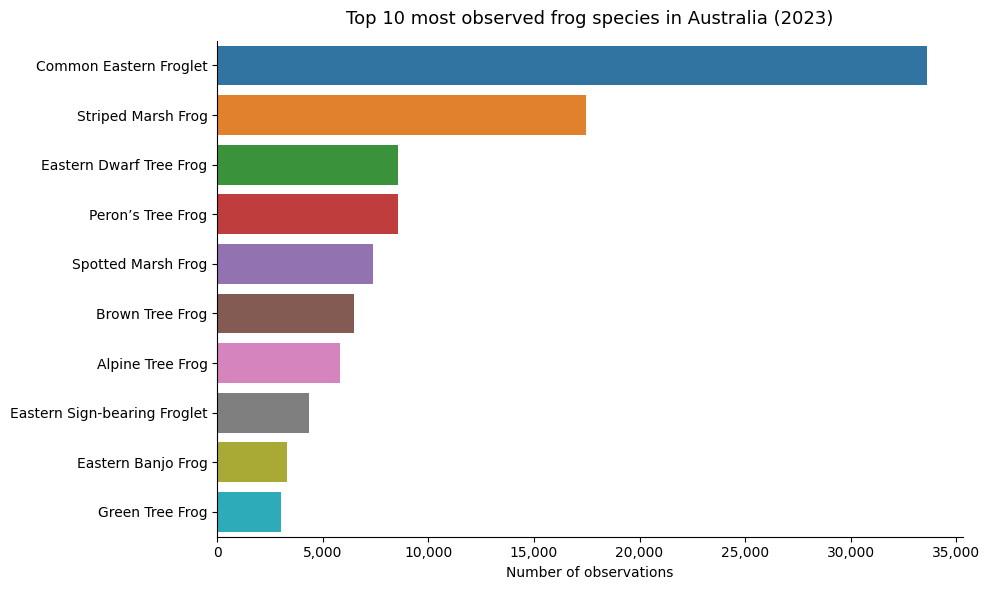

In [22]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

top10 = frog_data_merged.groupby('commonName').size().reset_index(name='count').sort_values('count', ascending=False).head(10)

colors = list(plt.get_cmap('tab10', len(top10)).colors)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(data=top10, x='count', y='commonName', hue='commonName', palette=colors, legend=False, errorbar=None, ax=ax)

ax.set_title('Top 10 most observed frog species in Australia (2023)', fontsize=13, pad=12)
ax.set_xlabel('Number of observations')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()
plt.savefig('plots/plot1_top10_species.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# get subfamilies of the top 10 most observed species
top10_species = top10['commonName'].tolist()
top10_scientific = frog_names_clean[frog_names_clean['commonName'].isin(top10_species)][['scientificName', 'commonName', 'subfamily']]
print("Top 10 most observed species with their scientific names and subfamilies:")
print(top10_scientific)

Top 10 most observed species with their scientific names and subfamilies:
                 scientificName                    commonName      subfamily
28             Litoria caerulea               Green Tree Frog          Hylid
45              Litoria ewingii               Brown Tree Frog          Hylid
46               Litoria fallax       Eastern Dwarf Tree Frog          Hylid
74              Litoria peronii             Peron’s Tree Frog          Hylid
97           Litoria verreauxii              Alpine Tree Frog          Hylid
144     Limnodynastes dumerilii            Eastern Banjo Frog   Myobatrachid
152       Limnodynastes peronii            Striped Marsh Frog   Myobatrachid
155  Limnodynastes tasmaniensis            Spotted Marsh Frog   Myobatrachid
204       Crinia parinsignifera  Eastern Sign-bearing Froglet   Myobatrachid
208            Crinia signifera        Common Eastern Froglet   Myobatrachid


### 3.2. Monthly observations by region<a id='toc3_2_'></a>

This line chart shows how the number of frog observations varies month by month across five geographic regions. The variables used are `month_name`, observation count, and `region` (derived from `stateProvince`). A line chart is ideal here because it emphasises the continuous trend shape across the temporal axis, and multiple lines can be overlaid cleanly without overcrowding. The month ordering follows the calendar year from January to November, reflecting the dataset coverage.

In [24]:
region_monthly = frog_data_merged.groupby(['month', 'month_name', 'region']).size().reset_index(name='count').sort_values('month')
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

region_monthly['month_name'] = pd.Categorical(
    region_monthly['month_name'], categories=month_order, ordered=True
)
region_colors = {
    'North': '#1f77b4',
    'North/West': '#ff7f0e',
    'South/East': '#2ca02c',
    'South': '#d62728',
    'Other': '#9467bd'
}

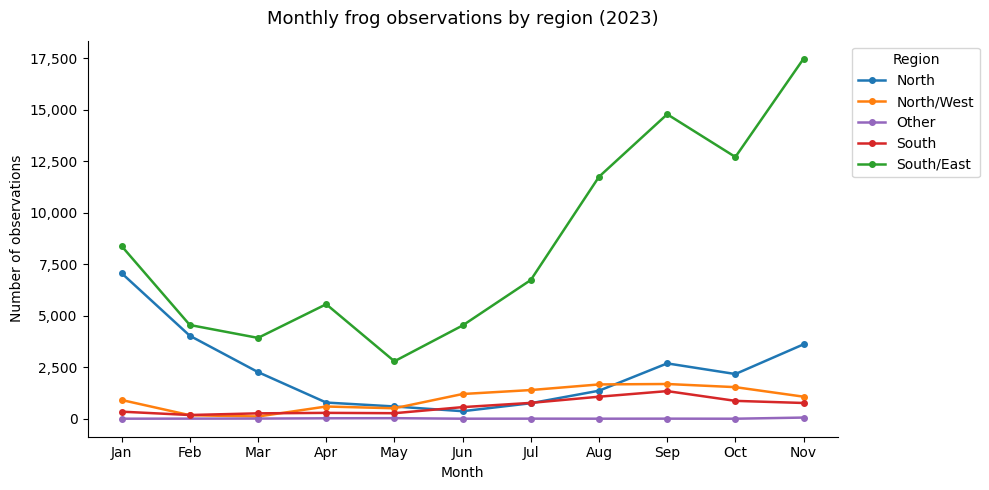

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))

for region, grp in region_monthly.groupby('region'):
    ax.plot(
        grp['month_name'],
        grp['count'],
        marker='o',
        markersize=4,
        label=region,
        color=region_colors.get(region, '#888780'),
        linewidth=1.8
    )

ax.set_title('Monthly frog observations by region (2023)', fontsize=13, pad=12)
ax.set_xlabel('Month')
ax.set_ylabel('Number of observations')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Region', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig('plots/plot2_observation_count_by_month_and_region.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3. Seasonal observation density map<a id='toc3_3_'></a>

This 2x2 panel map shows the geographic density of frog observations across Australia for each of the four Southern Hemisphere seasons. The variables used are `decimalLatitude`, `decimalLongitude`, and `season` (derived from `month`). A hexbin density map is ideal for this volume of data (~136,000 points) as while individual scatter points would overlap unreadably, hexagonal binning aggregates nearby observations into colour-encoded cells that reveal spatial clusters clearly. The dashed blue line in each panel marks the mean latitude of observations for that season, providing a direct visual indicator of whether the geographic centre of activity shifts northward or southward across the year.

In [26]:
def month_to_season(month):
    if month in [12, 1, 2]:  return 'Summer'
    elif month in [3, 4, 5]: return 'Autumn'
    elif month in [6, 7, 8]: return 'Winter'
    else:                    return 'Spring'

frog_data_merged['season'] = frog_data_merged['month'].apply(month_to_season)

season_order = ['Summer', 'Autumn', 'Winter', 'Spring']
season_counts = frog_data_merged['season'].value_counts()

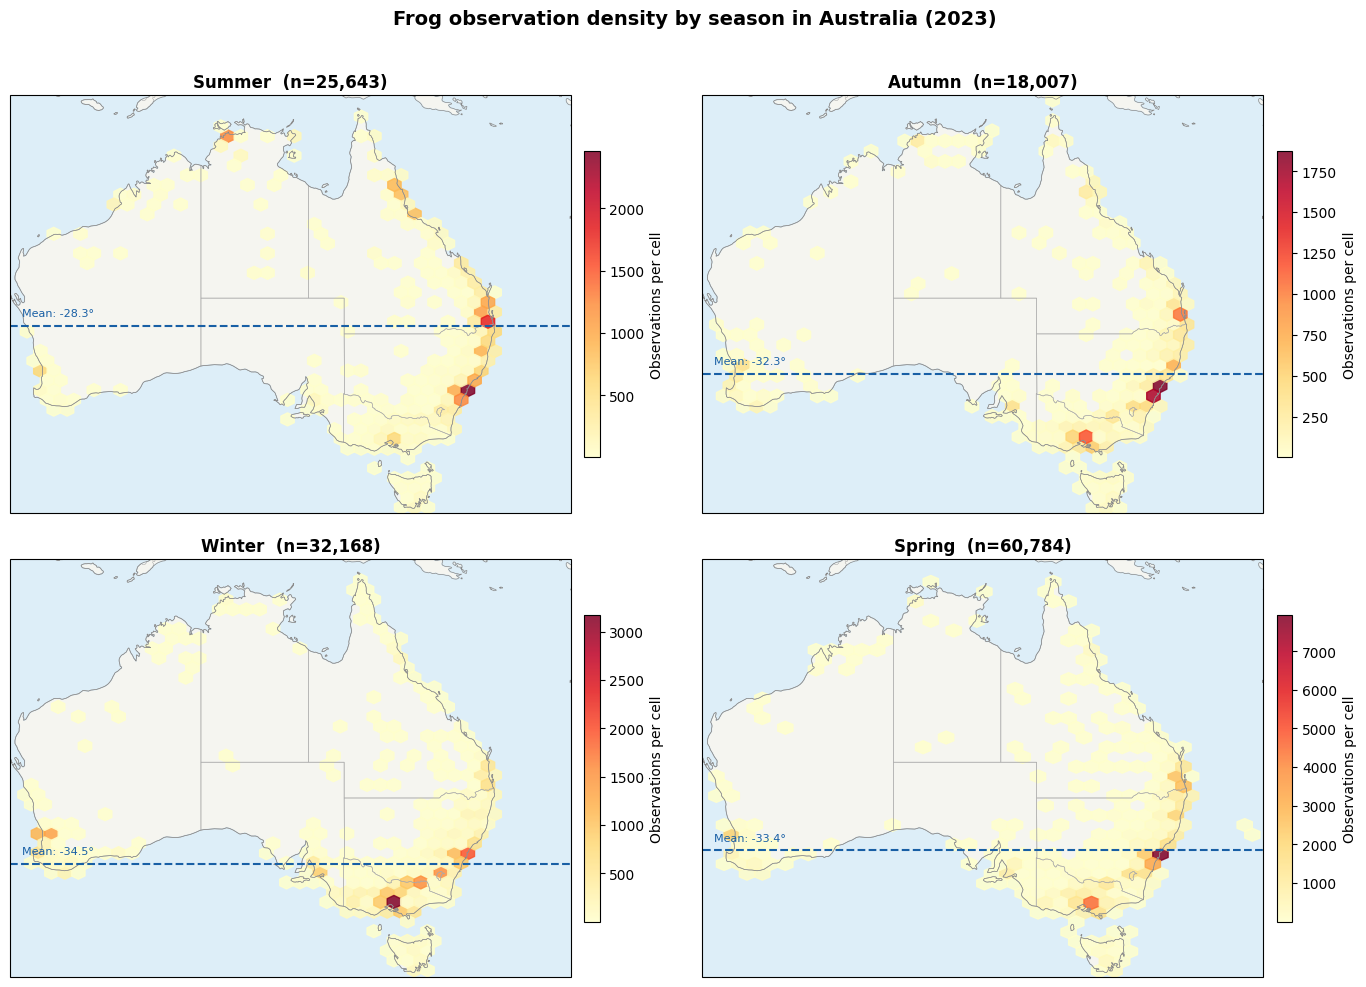

In [27]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10),
                         subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, season in enumerate(season_order):
    ax = axes[i]
    sd = frog_data_merged[frog_data_merged['season'] == season]
    mean_lat = sd['decimalLatitude'].mean()

    ax.set_extent([113, 160, -44, -9], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND,      color='#f5f5f0')
    ax.add_feature(cfeature.OCEAN,     color='#ddeef8')
    ax.add_feature(cfeature.STATES,    edgecolor='#aaaaaa', linewidth=0.4)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='#888888')

    hb = ax.hexbin(
        sd['decimalLongitude'],
        sd['decimalLatitude'],
        gridsize=35,
        cmap='YlOrRd',
        mincnt=1,
        alpha=0.85,
        transform=ccrs.PlateCarree()
    )

    # Mean latitude line — the key visual for the hypothesis
    ax.axhline(
        y=mean_lat,
        color='#185FA5',
        linewidth=1.5,
        linestyle='--'
    )
    ax.text(
        114, mean_lat + 0.8,
        f'Mean: {mean_lat:.1f}°',
        fontsize=8, color='#185FA5',
        transform=ccrs.PlateCarree()
    )
    n = season_counts[season]
    ax.set_title(f'{season}  (n={n:,})', fontsize=12, fontweight='bold', pad=6)
    plt.colorbar(hb, ax=ax, label='Observations per cell', shrink=0.65, pad=0.02)

fig.suptitle(
    'Frog observation density by season in Australia (2023)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('plots/plot3_seasonal_map.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Discussion<a id='toc4_'></a>

**Plot 1 - Top 10 most observed species** 

The Common Eastern Froglet dominates the observation record by a substantial margin, reflecting both its widespread distribution across southeastern Australia and its loud, distinctive call that makes it easily identifiable via the FrogID app. The top 10 species are drawn exclusively from two families — Hylidae (tree frogs) and Myobatrachidae (ground frogs) — suggesting that more acoustically conspicuous species are disproportionately represented in citizen science data. This observer bias is an important caveat when interpreting the spatial and temporal patterns in subsequent plots.

**Plot 2 — Monthly observations by region** 

Observation activity is not uniform across the year. The South/East region, which includes New South Wales and Victoria, consistently records the highest absolute counts and shows a pronounced peak in spring (September–November), consistent with the breeding season of many southeastern species. Northern regions show a comparatively flatter seasonal profile with modest activity during the wet season months. This divergence supports the hypothesis that seasonal patterns differ by region, though the dominance of South/East observations likely reflects the higher density of FrogID app users in major population centres such as Sydney and Melbourne rather than a purely ecological signal.

**Plot 3 — Seasonal density map** 

The spatial density maps confirm the concentration of observations along the eastern seaboard and southeastern corner of Australia across all four seasons. The mean latitude line shifts slightly southward during Spring and Summer (approximately -33° to -34°) compared to Winter and Autumn (approximately -31° to -32°), suggesting a modest southward shift in the centre of observed activity during warmer months. However, the overall geographic pattern remains largely stable across seasons, with the eastern coast dominating in all panels.

**Conclusion**

Taken together, the three visualisations reveal that frog observation patterns in Australia in 2023 are shaped by a combination of ecological and sociological factors. Seasonality drives temporal peaks, particularly in southeastern Australia during spring. Geographic patterns are relatively stable across seasons but show a modest southward shift in warmer months. The dominance of a small number of common, easily identified species and the concentration of observations in densely populated regions highlights an inherent limitation of citizen science data that should be considered when drawing ecological conclusions.

## 5. Teamwork<a id='toc5_'></a>

This project was completed collaboratively by all five members. The research question 
was formulated jointly by the group. Shreya Sriram led the data loading, cleaning, and 
preprocessing pipeline and developed the seasonal observation density map (Plot 3). 
Person 1 drafted the Introduction and Dataset sections. Person 2 developed the 
visualisation code for Plots 1 and 2. Person 3 wrote the Discussion section. 
Person 4 worked on the overall write-up. All members 
reviewed the final notebook and verified the reproducibility of the submitted results.

## 6. References<a id='toc6_'></a>

1. Australian Museum. (2023). *FrogID Dataset v6.0*. TidyTuesday repository, Week 35, 2025. https://github.com/rfordatascience/tidytuesday/tree/main/data/2025/2025-09-02
2. Australian Museum. (2023). *FrogID — Frogs of Australia*. https://www.frogid.net.au/frogs
3. Rowley, J., & Gillard, G. (2026, January 20). Citizen scientists are spotting more 
and more rare frogs on private land. The Conversation. 
https://theconversation.com/citizen-scientists-are-spotting-more-and-more-rare-frogs-on-private-land-271850